# Regras de associação

A base de dados é composta por **145** características e **9'112** entradas.

Existe **5'011** duplicadas, que decidimos não remover, por considerar que pessoas diferentes poderiam de fato fazer as mesmas compras.


In [85]:
%%html
<link rel="stylesheet" href="./style.css">

import import_ipynb  # noqa: F401

In [86]:
import pandas as pd
from IPython.display import HTML, display
from mlxtend.frequent_patterns import apriori, association_rules

from columns import columns_names
from data import df
from plotting import plot_bar_graph


## Transações


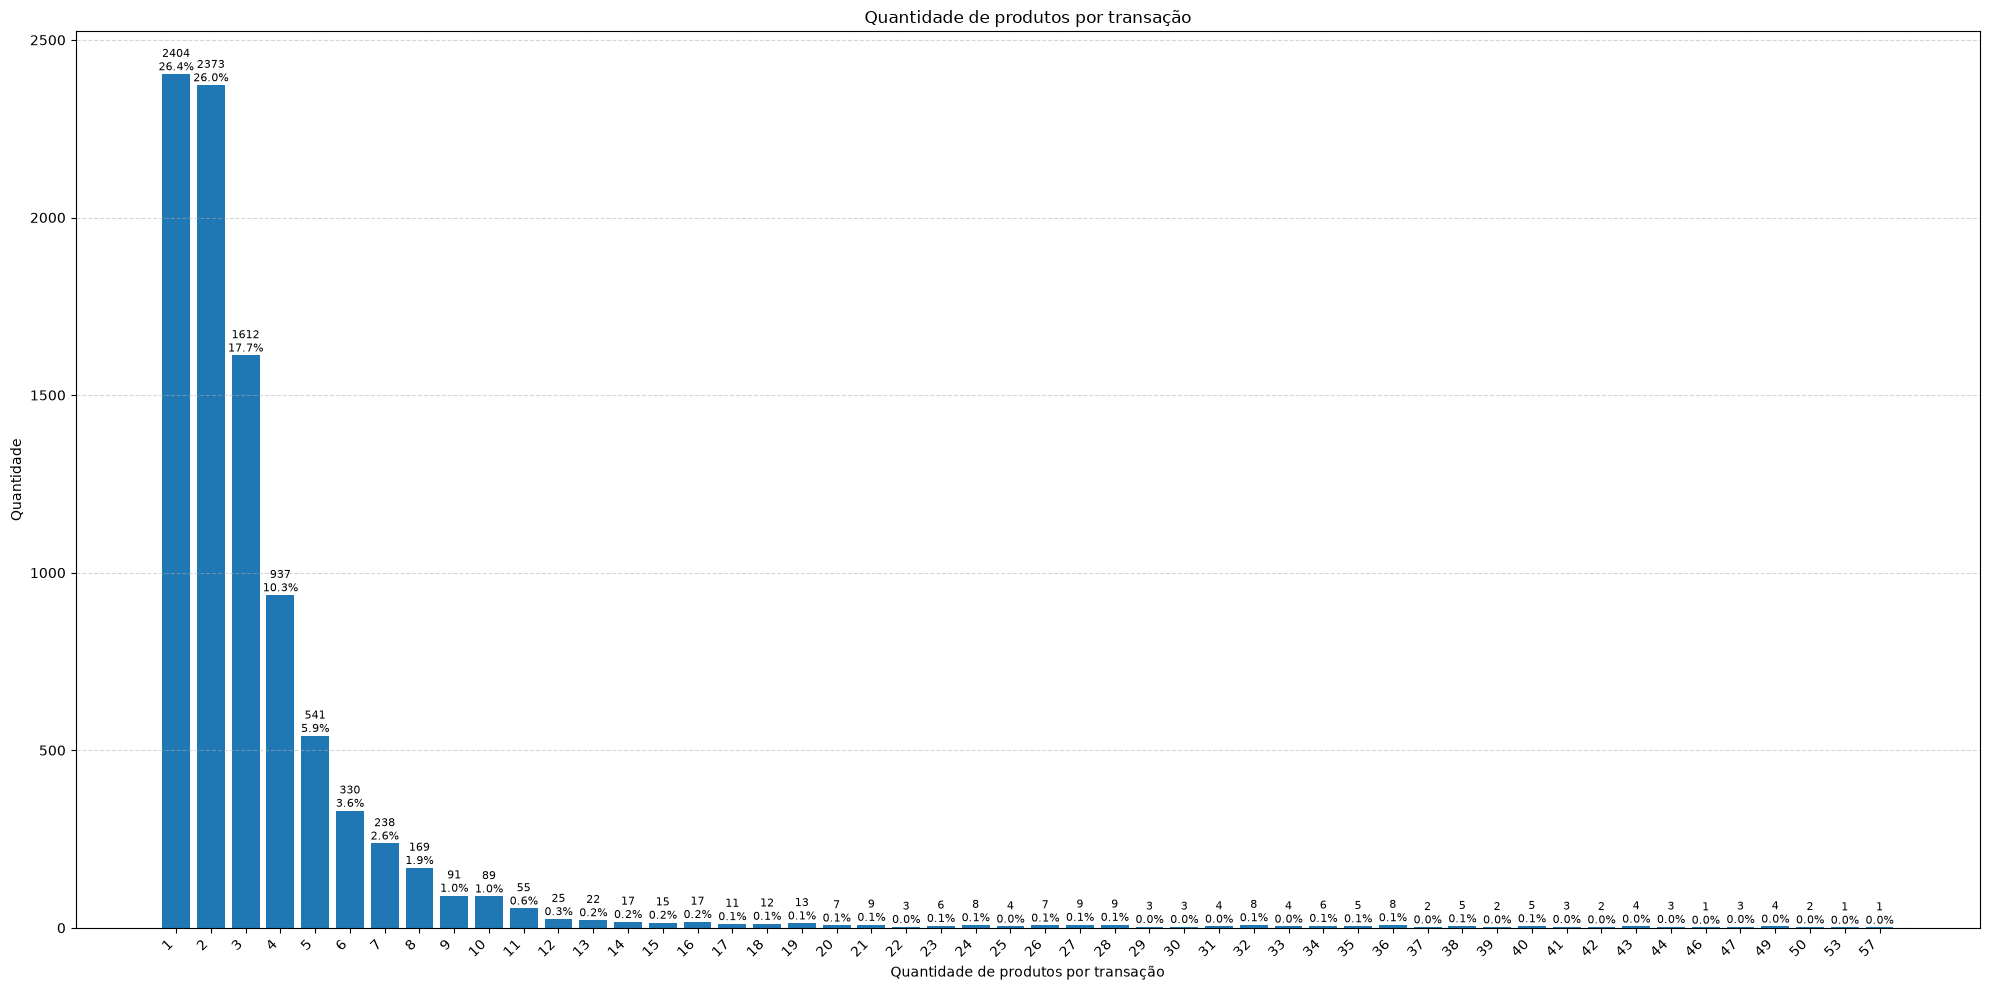

In [87]:
products_per_transaction = df.sum(axis=1).sort_values(ascending=False)
transaction_counts = products_per_transaction.value_counts()

plot_bar_graph(
    transaction_counts,
    label="Quantidade de produtos por transação",
    title="Quantidade de produtos por transação",
    show_percentage=True,
    show_value=True,
    y_tick_step=500,
    sort_by="natural",
)

## Produtos frequentes


### Menos frequentes


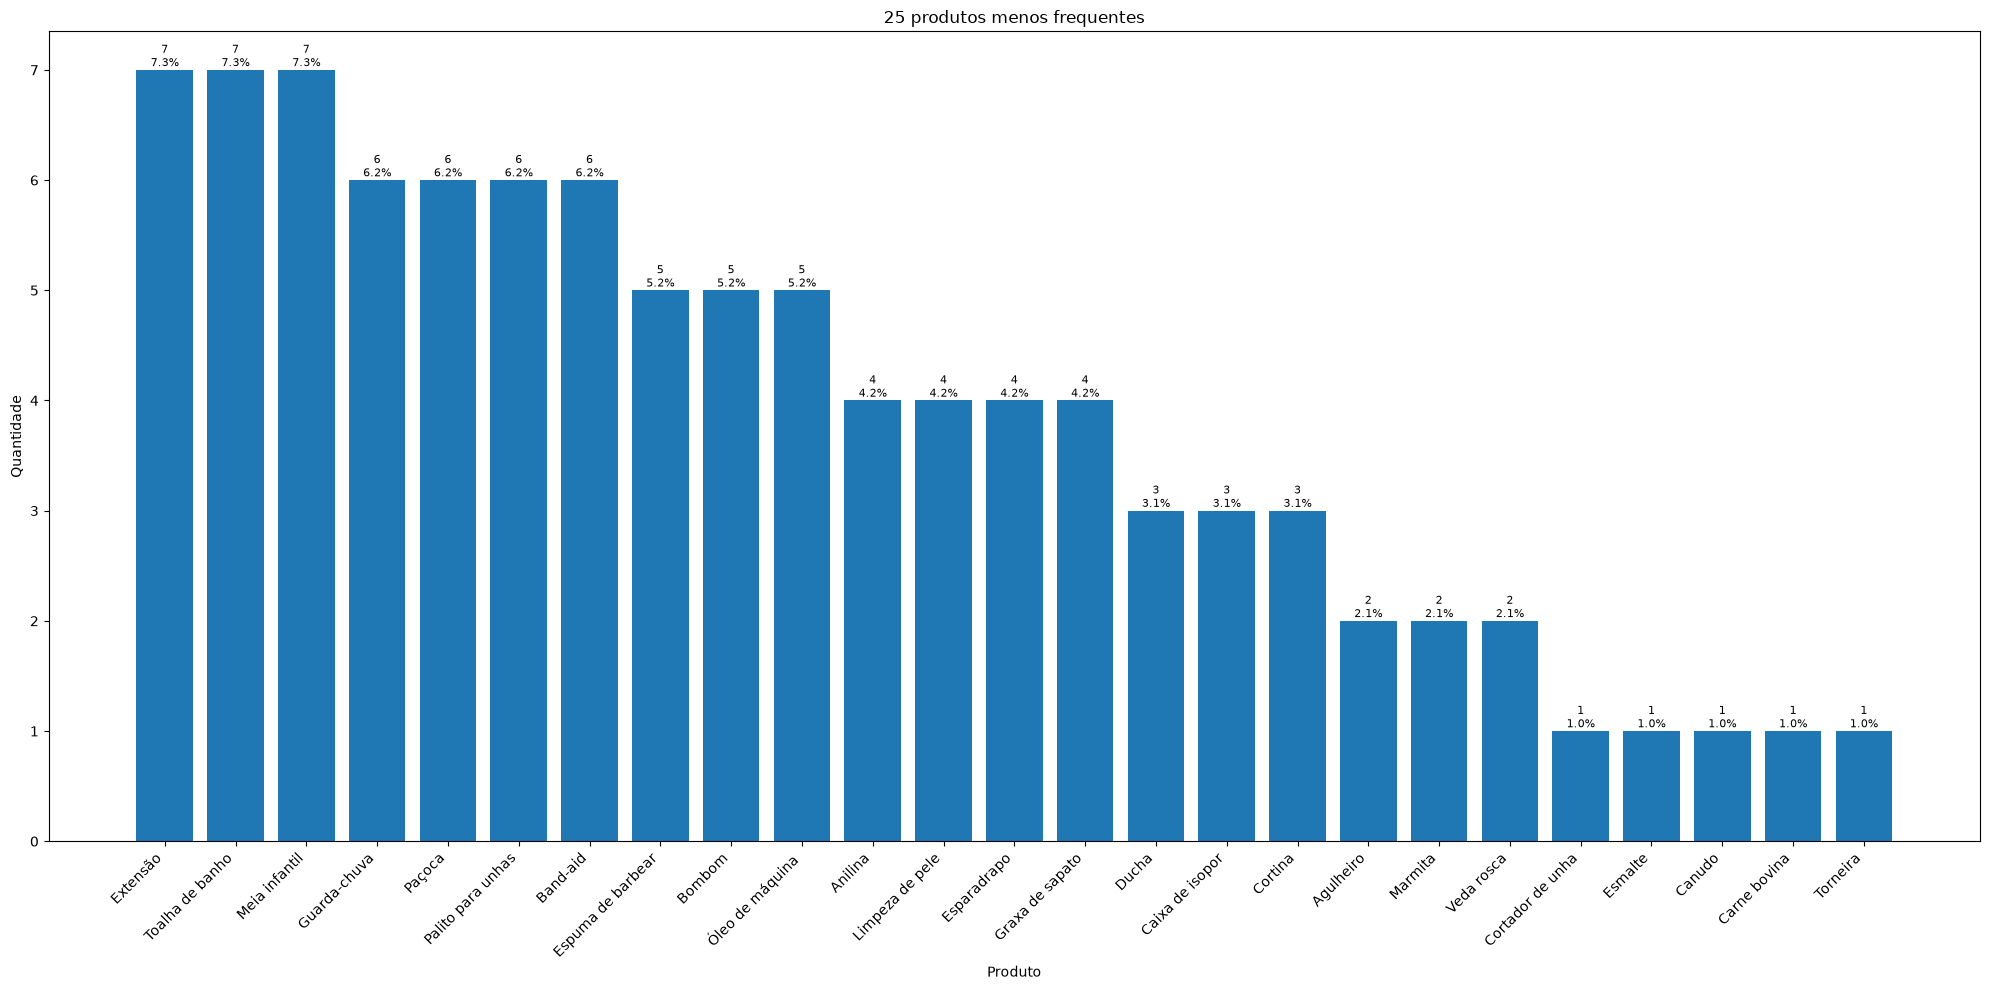

In [88]:
frequencies = df.sum().sort_values(ascending=False)

top_products = frequencies.tail(25).rename(index=dict(zip(df.columns, columns_names())))

plot_bar_graph(
    top_products,
    label="Produto",
    title="25 produtos menos frequentes",
    show_percentage=True,
    show_value=True,
    # y_tick_step=500,
    sort_by="frequency",
)

### Mais frequentes


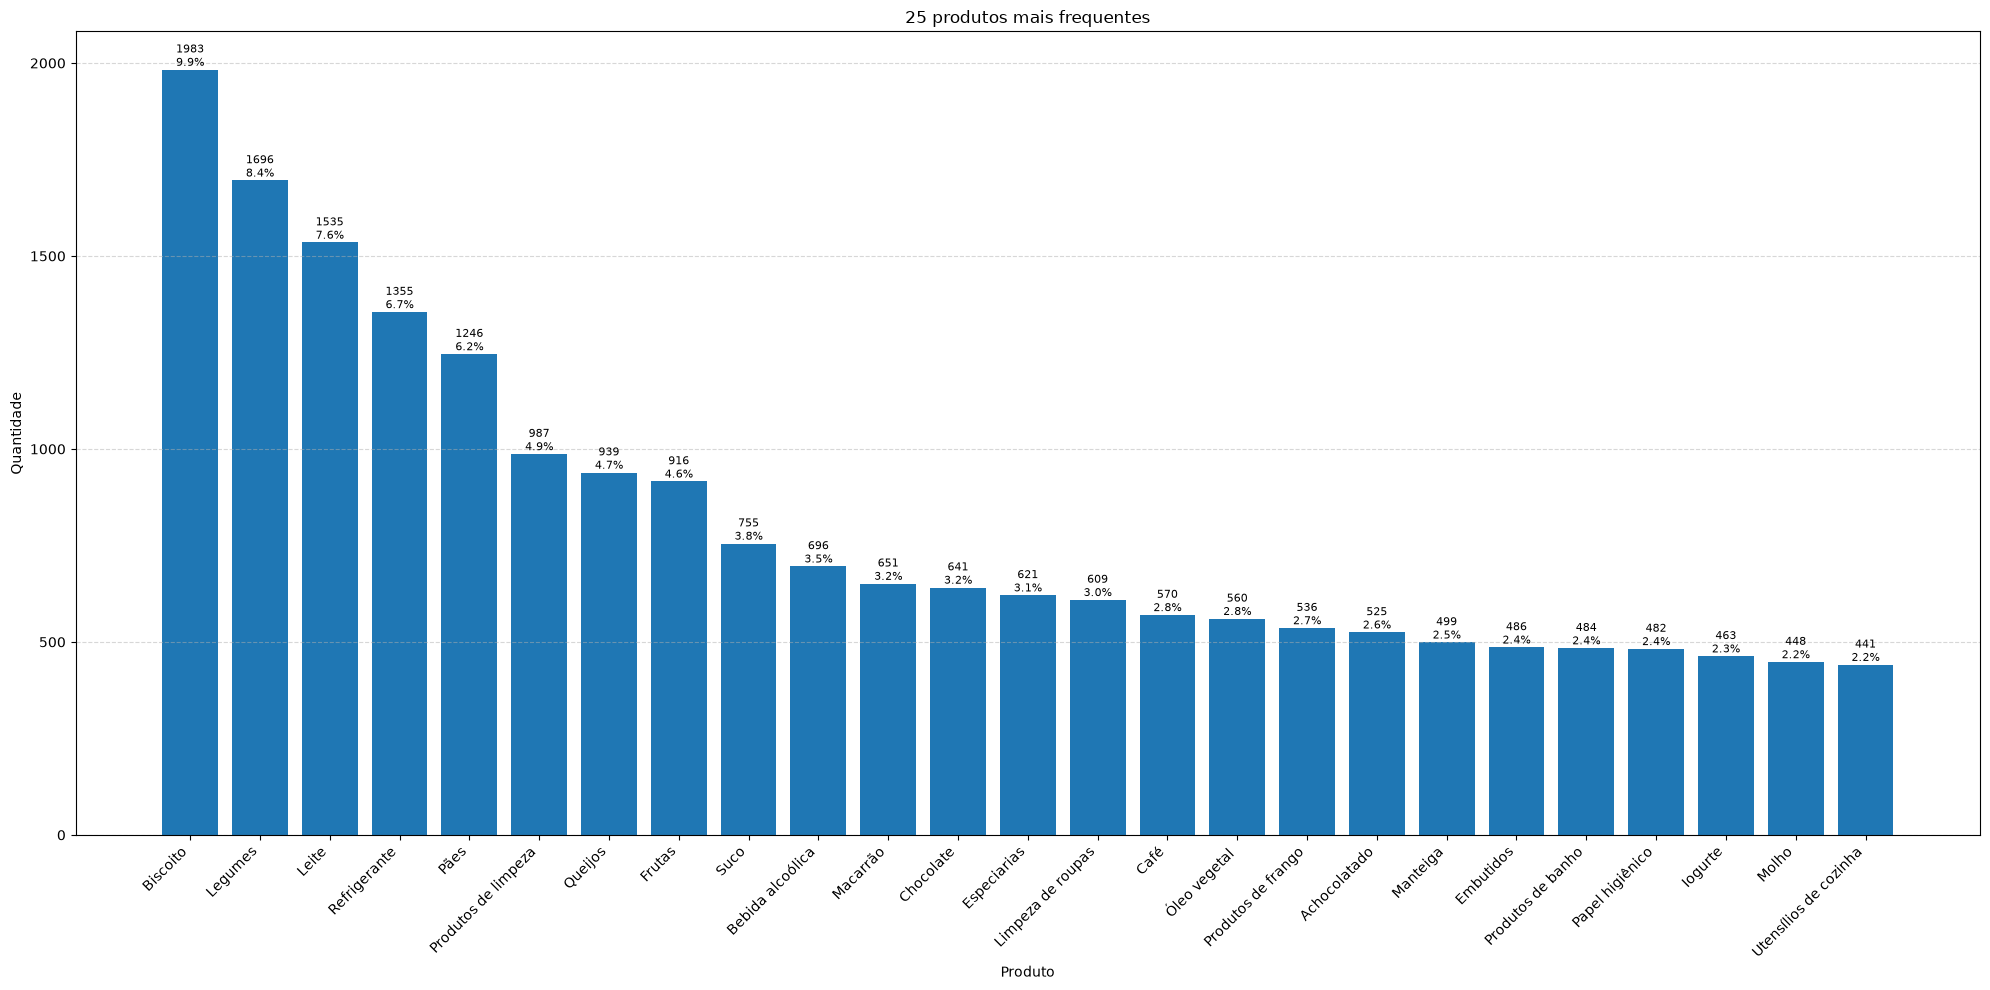

In [89]:
frequencies = df.sum().sort_values(ascending=False)

top_products = frequencies.head(25).rename(index=dict(zip(df.columns, columns_names())))

plot_bar_graph(
    top_products,
    label="Produto",
    title="25 produtos mais frequentes",
    show_percentage=True,
    show_value=True,
    y_tick_step=500,
    sort_by="frequency",
)

## Associações


### Apriori

#### Análise de valor de suporte

<!-- Fixamos o threshold de confiança em `0.8`. -->


In [90]:
def generate_itemsets(data_frame: pd.DataFrame, min_support: float) -> pd.DataFrame:
    itemsets = apriori(data_frame, min_support=min_support, use_colnames=True)

    itemsets["itemset_size"] = itemsets["itemsets"].apply(len)
    itemsets["transaction_count"] = (
        (itemsets["support"] * len(data_frame)).round().astype(int)
    )

    return itemsets

In [91]:
def display_itemsets(
    itemsets: pd.DataFrame,
    min_support: float,
):
    table_code = f"""
    <table>
        <caption>
            Frequent itemsets — minimum support = {min_support:.3f}
        </caption>
        <thead>
            <tr>
                <th>Itemset</th>
                <th>Size</th>
                <th>Support</th>
                <th>Transactions</th>
            </tr>
        </thead>
        <tbody>
    """

    for _, row in itemsets.iterrows():
        items = ", ".join(sorted(row["itemsets"]))

        table_code += f"""
            <tr>
                <td>{{items}}</td>
                <td>{row["itemset_size"]}</td>
                <td>{row["support"]:.4f}</td>
                <td>{row["transaction_count"]}</td>
            </tr>
        """

    table_code += """
        </tbody>
    </table>
    """

    display(HTML(table_code))

In [92]:
def analyze_support(
    data_frame: pd.DataFrame,
    min_support: float,
) -> pd.DataFrame:
    itemsets = generate_itemsets(data_frame, min_support)

    display_itemsets(itemsets, min_support)

    return itemsets

In [93]:
def summarize_support(
    data_frame: pd.DataFrame,
    support_values: list[float],
) -> pd.DataFrame:
    results = []

    for support in support_values:
        itemsets = generate_itemsets(data_frame, support)

        results.append(
            {
                "Support": support,
                "itemsets": len(itemsets),
                "1-itemsets": (itemsets["itemset_size"] == 1).sum(),
                "2-itemsets": (itemsets["itemset_size"] == 2).sum(),
                "3-itemsets": (itemsets["itemset_size"] == 3).sum(),
                "4+-itemsets": (itemsets["itemset_size"] >= 4).sum(),
            }
        )

    return pd.DataFrame(results)

In [99]:
support_values = [0.01, 0.02, 0.03, 0.05, 0.10]

support_summary = summarize_support(df, support_values)

display(HTML(support_summary.to_html(index=False, float_format="{:.2f}".format)))

Support,itemsets,1-itemsets,2-itemsets,3-itemsets,4+-itemsets
0.01,1299,72,352,455,420
0.02,121,48,72,1,0
0.03,64,41,22,1,0
0.05,23,23,0,0,0
0.10,8,8,0,0,0


- Considerando um valor mínimo de suporte de `1%`, um conjunto muito grande de itemsets é encontrado, o que não distingue muita informação.
- Para o valor de `2%`, percebe-se uma redução acentuada da quantidade de itemsets, o que permite separar bastante as regras realmente úteis.
- O valor de `3%` acompanha a interpretação de `2%`, porém mais restrito.
- Os valores de `5%` e `10%` restringem demais a identificação de itemsets, e perdem informação interessante.


In [100]:
support_values = [0.010, 0.0125, 0.015, 0.0175, 0.020]

support_summary = summarize_support(df, support_values)

display(HTML(support_summary.to_html(index=False, float_format="{:.4f}".format)))

Support,itemsets,1-itemsets,2-itemsets,3-itemsets,4+-itemsets
0.0100,1299,72,352,455,420
0.0125,462,64,225,158,15
0.0150,232,56,150,26,0
0.0175,166,53,111,2,0
0.0200,121,48,72,1,0


- O valor de `1.25%` delimita expressivamente a quantidade de itemsets, mas ainda preserva `15` conjuntos grandes.
- Valores maiores restringem bastante, e perdem informação.
